In [1]:
import geopandas as gpd
import pandas as pd
import shapely
import json
import contextily as cx

In [2]:
fields = pd.read_csv("../data/central_valley_polygons.csv")
fields["coords"] = fields[".geo"].apply(lambda x: pd.Series(dict(json.loads(x))))['coordinates']
fields["geometry"] = fields['coords'].apply(lambda x: shapely.Polygon(list(zip(x[::2], x[1::2]))))
fields = fields[["OPENET_ID", "CROP_2023", "geometry"]]
fields = gpd.GeoDataFrame(fields, geometry='geometry', crs="EPSG:4326")

fields

,OPENET_ID,CROP_2023,geometry
0,CA_258026,61,"POLYGON ((-119.2746 35.60554, -119.27453 35.60..."
1,CA_258017,47,"POLYGON ((-119.16004 35.55876, -119.15574 35.5..."
2,CA_257983,47,"POLYGON ((-119.13782 35.57572, -119.13775 35.5..."
3,CA_257978,47,"POLYGON ((-119.09166 35.63817, -119.09155 35.6..."
4,CA_257950,47,"POLYGON ((-119.10776 35.63568, -119.10464 35.6..."
...,...,...,...
1809,CA_297950,204,"POLYGON ((-119.77533 36.48573, -119.77095 36.4..."
1810,CA_297932,204,"POLYGON ((-119.96531 36.47736, -119.96529 36.4..."
1811,CA_297927,61,"POLYGON ((-119.93837 36.41342, -119.93814 36.4..."
1812,CA_297922,75,"POLYGON ((-119.78577 36.52547, -119.78572 36.5..."


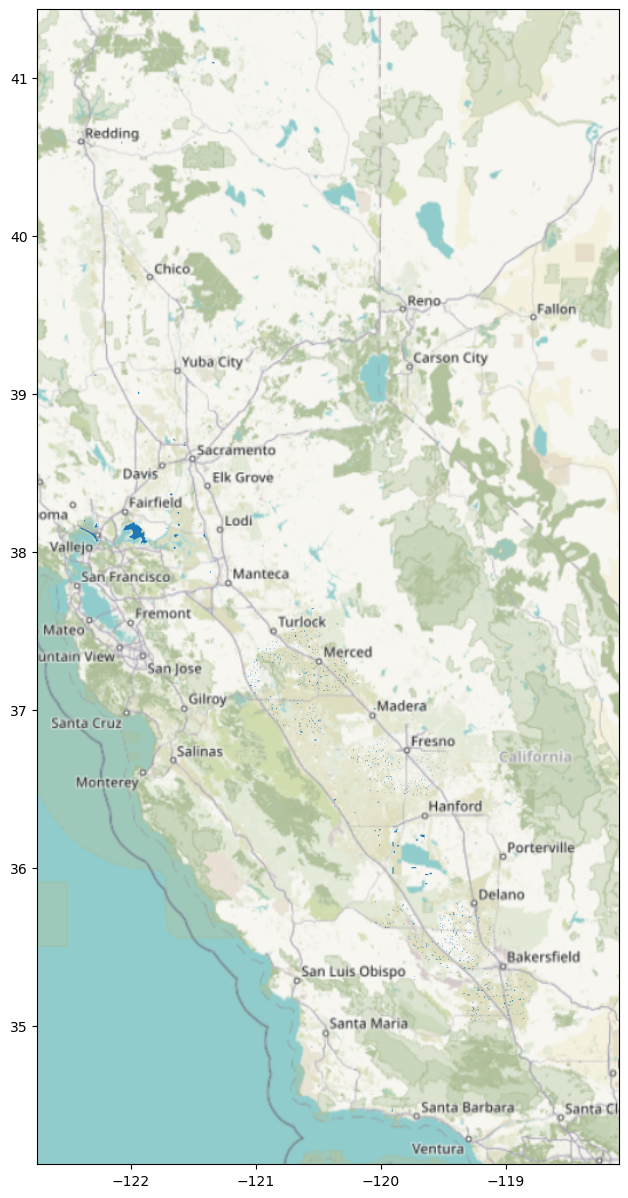

In [3]:
ax = fields.plot(figsize=(25, 15))
cx.add_basemap(ax, crs=fields.crs, attribution=False, source=cx.providers.OpenStreetMap.HOT)

In [4]:
gsa = gpd.read_file("~/Desktop/EarthEngineExports/cv_gsas.shp")
gsa.head()

,Basin_Subb,Basin_ID,Comments,GW_Budget_,Subbasin_N,Shape_ST_2,Shape_ST_1,Shape_STAr,Region_Off,BasinSubba,Basin_Name,Shape_STLe,Record_Edi,geometry
0,5-06.01,5-06,None,B,BOWMAN,117642.599795,3.176157e+08,3.176157e+08,1,2,REDDING AREA,117642.599795,None,"POLYGON ((-122.62268 40.23872, -122.62077 40.2..."
1,5-06.02,5-06,None,B,ROSEWOOD,80361.238465,1.881398e+08,1.881398e+08,1,2,REDDING AREA,80361.238465,None,"POLYGON ((-122.62823 40.32012, -122.62822 40.3..."
2,5-06.06,5-06,None,B,SOUTH BATTLE CREEK,58756.021663,1.370183e+08,1.370183e+08,1,2,REDDING AREA,58756.021663,None,"POLYGON ((-122.20597 40.32899, -122.20574 40.3..."
3,5-06.03,5-06,None,B,ANDERSON,118838.318509,3.922609e+08,3.922609e+08,1,2,REDDING AREA,118838.318509,None,"POLYGON ((-122.55194 40.4862, -122.55191 40.48..."
4,5-06.05,5-06,None,B,MILLVILLE,86612.160023,2.641450e+08,2.641450e+08,1,2,REDDING AREA,86612.160023,None,"POLYGON ((-122.23459 40.54302, -122.23362 40.5..."


<Axes: >

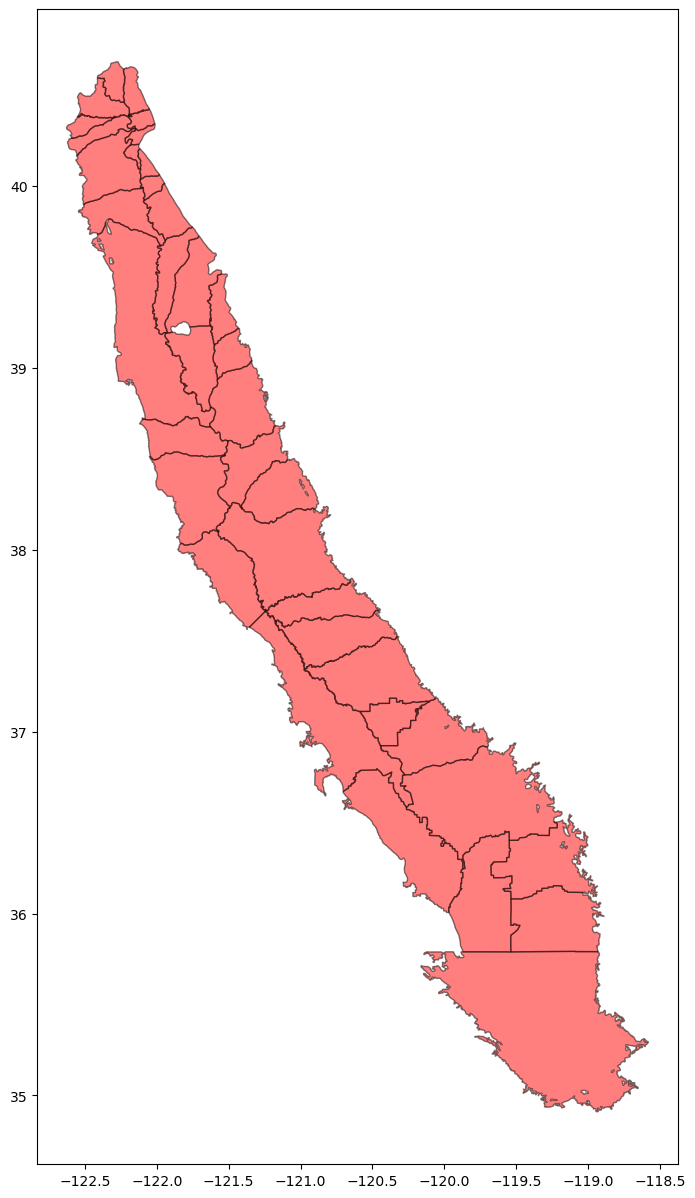

In [5]:
gsa.plot(figsize=(25, 15), color='red', alpha=0.5, edgecolor='black')

<Axes: >

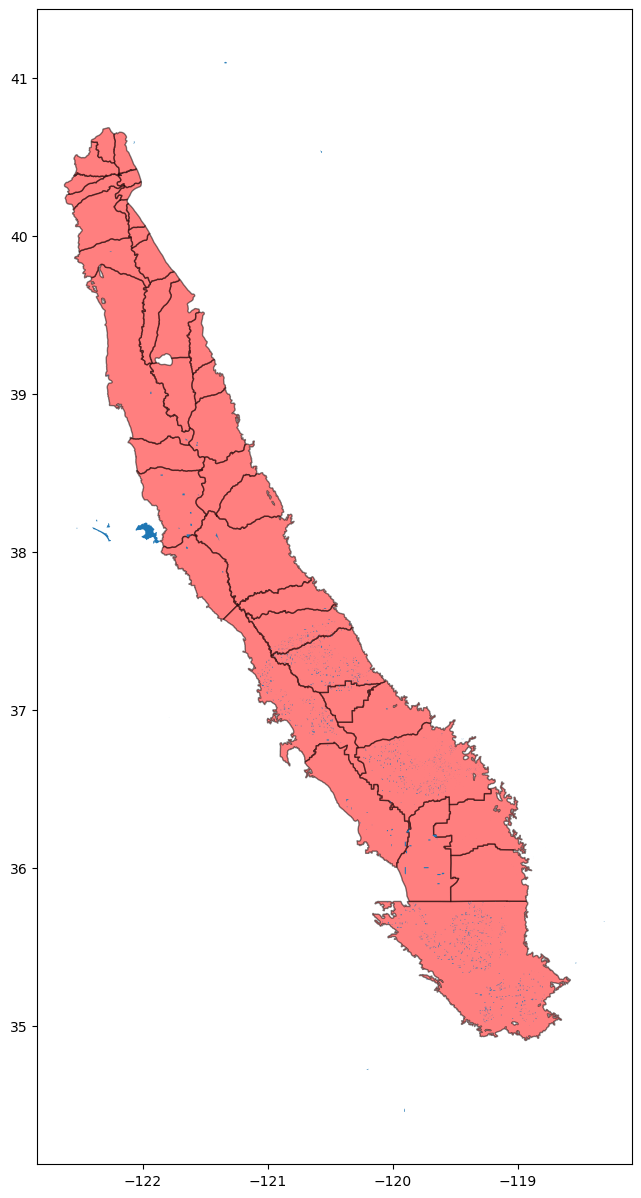

In [6]:
ax = gsa.plot(figsize=(25, 15), color='red', alpha=0.5, edgecolor='black')
fields.plot(figsize=(25, 15), ax=ax)

/tmp/ipykernel_1724441/2803902011.py:1: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  intersection = gpd.overlay(fields, gsa, how='intersection')


<Axes: >

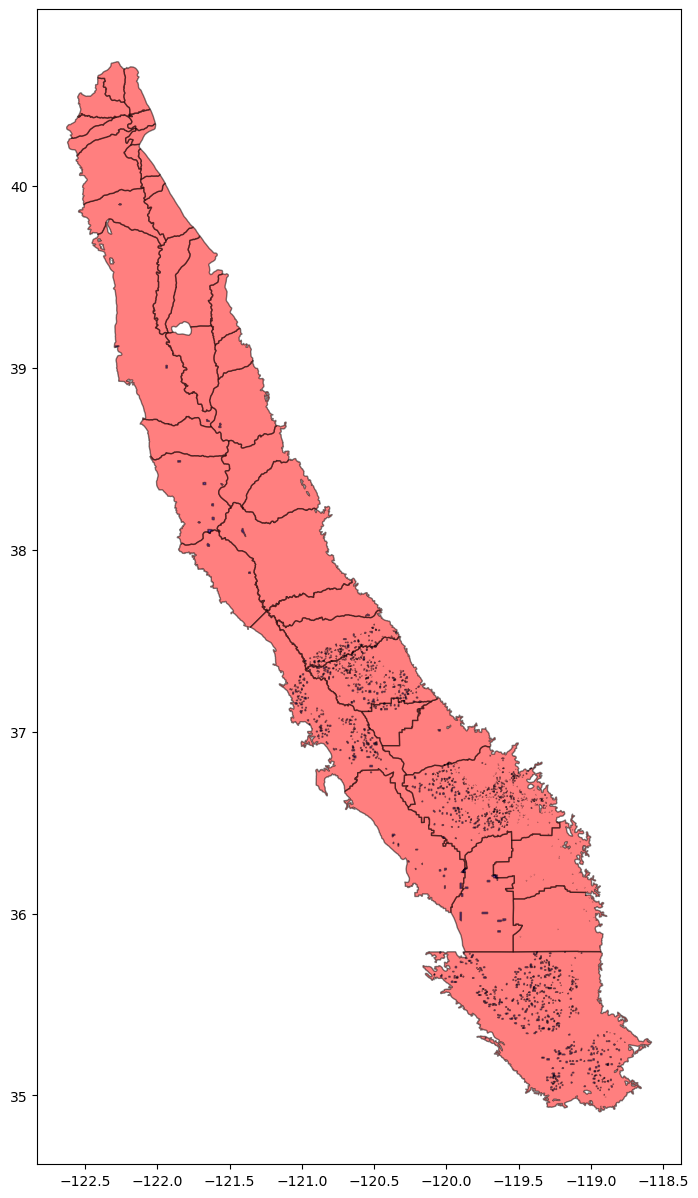

In [7]:
intersection = gpd.overlay(fields, gsa, how='intersection')

ax = gsa.plot(figsize=(25, 15), color='red', alpha=0.5, edgecolor='black')
intersection.plot(figsize=(25, 15), color='blue', alpha=0.5, edgecolor='black', ax=ax)

In [21]:
intersection = intersection.query("Basin_Name == 'SAN JOAQUIN VALLEY'").drop_duplicates(subset=["OPENET_ID"]).reset_index()
intersection

,index,OPENET_ID,CROP_2023,Basin_Subb,Basin_ID,Comments,GW_Budget_,Subbasin_N,Shape_ST_2,Shape_ST_1,Shape_STAr,Region_Off,BasinSubba,Basin_Name,Shape_STLe,Record_Edi,geometry
0,0,CA_258026,61,5-22.14,5-22,None,A,KERN COUNTY,931702.579636,7.876280e+09,7.876280e+09,3,2,SAN JOAQUIN VALLEY,931702.579636,None,"POLYGON ((-119.27457 35.60891, -119.27252 35.6..."
1,1,CA_258017,47,5-22.14,5-22,None,A,KERN COUNTY,931702.579636,7.876280e+09,7.876280e+09,3,2,SAN JOAQUIN VALLEY,931702.579636,None,"POLYGON ((-119.16001 35.56229, -119.1558 35.56..."
2,2,CA_257983,47,5-22.14,5-22,None,A,KERN COUNTY,931702.579636,7.876280e+09,7.876280e+09,3,2,SAN JOAQUIN VALLEY,931702.579636,None,"POLYGON ((-119.13782 35.57655, -119.13754 35.5..."
3,3,CA_257978,47,5-22.14,5-22,None,A,KERN COUNTY,931702.579636,7.876280e+09,7.876280e+09,3,2,SAN JOAQUIN VALLEY,931702.579636,None,"POLYGON ((-119.09166 35.63842, -119.08945 35.6..."
4,4,CA_257950,47,5-22.14,5-22,None,A,KERN COUNTY,931702.579636,7.876280e+09,7.876280e+09,3,2,SAN JOAQUIN VALLEY,931702.579636,None,"POLYGON ((-119.10775 35.63692, -119.10771 35.6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1764,1791,CA_297962,61,5-22.08,5-22,None,C,KINGS,495252.608055,3.948962e+09,3.948962e+09,3,2,SAN JOAQUIN VALLEY,495252.608055,None,"POLYGON ((-119.83601 36.50296, -119.83598 36.5..."
1765,1792,CA_297950,204,5-22.08,5-22,None,C,KINGS,495252.608055,3.948962e+09,3.948962e+09,3,2,SAN JOAQUIN VALLEY,495252.608055,None,"POLYGON ((-119.77513 36.48926, -119.77077 36.4..."
1766,1793,CA_297932,204,5-22.08,5-22,None,C,KINGS,495252.608055,3.948962e+09,3.948962e+09,3,2,SAN JOAQUIN VALLEY,495252.608055,None,"POLYGON ((-119.95934 36.47732, -119.95935 36.4..."
1767,1794,CA_297927,61,5-22.08,5-22,None,C,KINGS,495252.608055,3.948962e+09,3.948962e+09,3,2,SAN JOAQUIN VALLEY,495252.608055,None,"POLYGON ((-119.9383 36.41359, -119.93833 36.41..."


<Axes: >

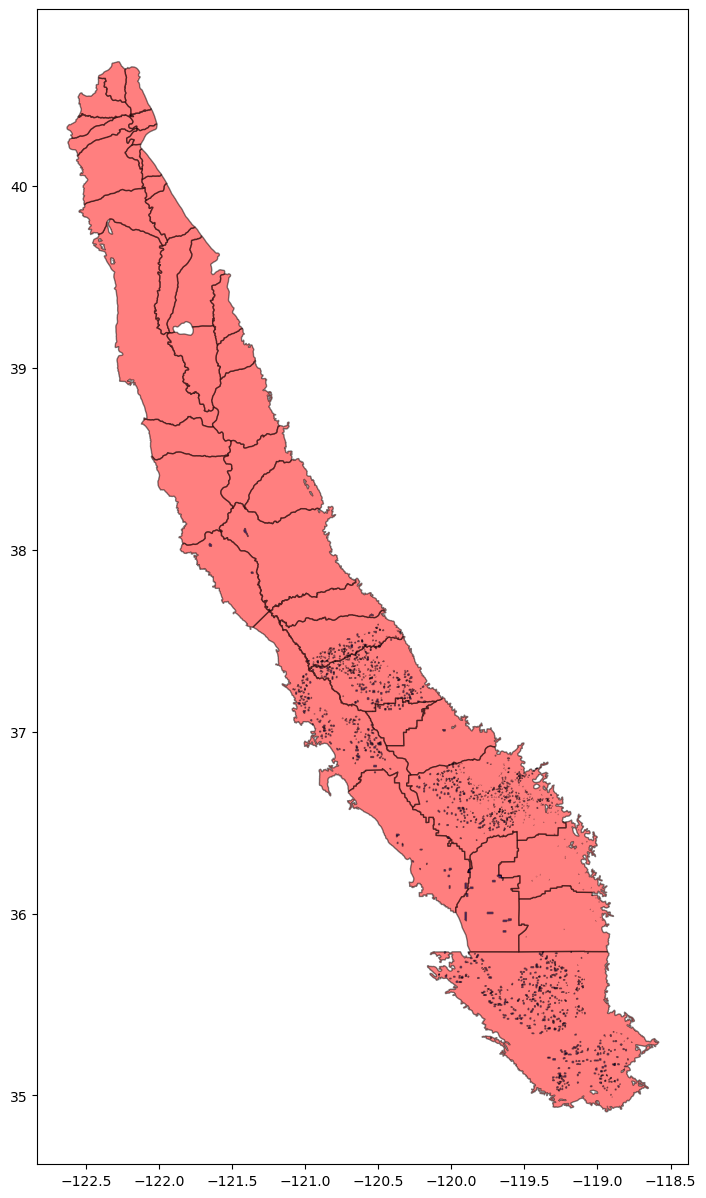

In [22]:
ax = gsa.plot(figsize=(25, 15), color='red', alpha=0.5, edgecolor='black')
intersection.plot(figsize=(25, 15), color='blue', alpha=0.5, edgecolor='black', ax=ax)

In [19]:
intersection[["OPENET_ID", "CROP_2023", "Basin_Name", "Subbasin_N", "geometry"]].to_file("../data/central_valley_gsa_intersection.shp", index=False)